# Train XGBoost (5-Fold CV)
Loads `X_2D.npy` and trains XGBoost using 5-Fold Cross Validation.

In [1]:
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [2]:
X_train = np.load('../dataset/X_train_2D.npy')
y_train = np.load('../dataset/y_train.npy')
X_test = np.load('../dataset/X_test_2D.npy')
y_test = np.load('../dataset/y_test.npy')
print('X_train shape:', X_train.shape, 'X_test shape:', X_test.shape)


X_train shape: (46606, 140) X_test shape: (10027, 140)


In [3]:
from sklearn.utils.class_weight import compute_sample_weight
start_time = time.time()
# Compute sample weights for multiclass loss
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
# Regularization limits via max_depth and learning_rate
model = XGBClassifier(eval_metric='mlogloss', max_depth=6, learning_rate=0.1, n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train, sample_weight=sample_weights)
end_time = time.time()
print(f"Training Time: {end_time - start_time:.2f} seconds")


Training Time: 9.98 seconds


Test Accuracy: 87.58%

Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.79      1302
           1       0.94      0.94      0.94      7610
           2       0.51      0.62      0.56      1115

    accuracy                           0.88     10027
   macro avg       0.78      0.76      0.76     10027
weighted avg       0.88      0.88      0.88     10027



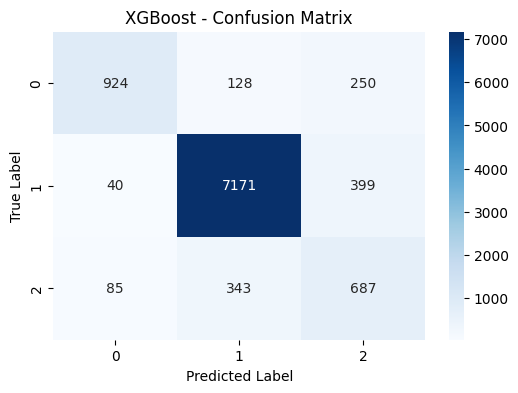

Model saved!


In [4]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print('\nTest Classification Report:')
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
joblib.dump(model, '../models/xgboost.pkl')
print('Model saved!')